**Feature selection context** — This time, `y = x**2` is the true relationship, but we deliberately engineer *three* candidate features (`x`, `x**2`, `x**3`) instead of just the one we know is correct. This mirrors a real scenario: you often don't know in advance which power of a feature actually matters — you let the model tell you, by checking which learned coefficient ends up largest (a small coefficient means that feature contributes little to the prediction).

**`np.c_[x, x**2, x**3]`** — Stacks three columns together into one `(m, 3)` matrix: column 0 is `x`, column 1 is `x**2`, column 2 is `x**3`. Since `y` was defined using `x**2`, we'd expect the model to learn a large coefficient for column 1 and small/near-zero coefficients for columns 0 and 2 — because those don't actually help predict `y`.

In [13]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features — candidates: x, x^2, x^3 (we don't assume we know x^2 is "the" answer)
X = np.c_[x, x**2, x**3]

model = LinearRegression()
model.fit(X, y)
print(f"w (coefficients for x, x^2, x^3): {model.coef_}")
print(f"b (intercept): {model.intercept_}")

w (coefficients for x, x^2, x^3): [-2.55333915e-14  1.00000000e+00 -2.37196706e-15]
b (intercept): 4.547473508864641e-12


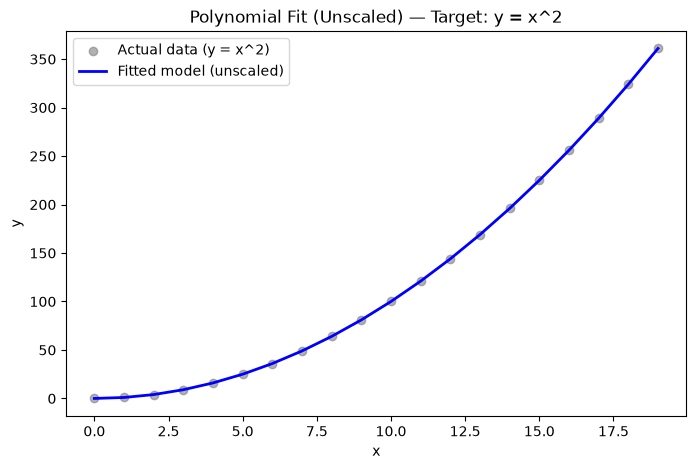

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='gray', label='Actual data (y = x^2)', alpha=0.6)
plt.plot(x, model.predict(X), color='blue', label='Fitted model (unscaled)', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Fit (Unscaled) — Target: y = x^2')
plt.legend()
plt.show()

**Why scaling becomes necessary** — Look at the magnitude gap between columns in `X` above: at `x=19`, `x=361`, `x**3=6859`. These wildly different scales cause two problems: (1) if you were using your own `gradient_descent` rather than scikit-learn's direct solver, a single `alpha` would be far too large for one column and far too small for another, making convergence difficult; (2) even with scikit-learn's solver, coefficient magnitudes become hard to compare directly across features when their scales differ so much — a large coefficient might just mean "this feature has small values," not "this feature matters more."

**`zscore_normalize_features`** — Applies the z-score formula column-by-column: $x_j^{(i)} \leftarrow \frac{x_j^{(i)} - \mu_j}{\sigma_j}$. After this, every column has mean 0 and standard deviation 1 — so coefficients become directly comparable, and the true importance of each feature (`x` vs `x^2` vs `x^3`) is easier to read off from the learned `w` values.

- `np.mean(X, axis=0)`: mean per column (per feature) — see earlier explanation of `axis=0`
- `np.std(X, axis=0)`: standard deviation per column, same `axis=0` logic

In [15]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)      # mean of each feature/column, shape (n,)
    sigma = np.std(X, axis=0)    # std dev of each feature/column, shape (n,)
    X_norm = (X - mu) / sigma    # broadcasts mu, sigma across all m rows
    return X_norm, mu, sigma

Re-running the same `x`, `x**2`, `x**3` feature set from Chunk 1, but scaled this time. Compare the resulting `model.coef_` against the unscaled version — the coefficient for column 1 (`x**2`) should stand out much more clearly relative to the other two, now that all three are on the same scale.

In [16]:
X = np.c_[x, x**2, x**3]
X_norm, mu, sigma = zscore_normalize_features(X)

model_scaled = LinearRegression()
model_scaled.fit(X_norm, y)
print(f"w (scaled, for x, x^2, x^3): {model_scaled.coef_}")
print(f"b (scaled): {model_scaled.intercept_}")

w (scaled, for x, x^2, x^3): [ 5.93111900e-13  1.13494714e+02 -4.89459906e-13]
b (scaled): 123.5


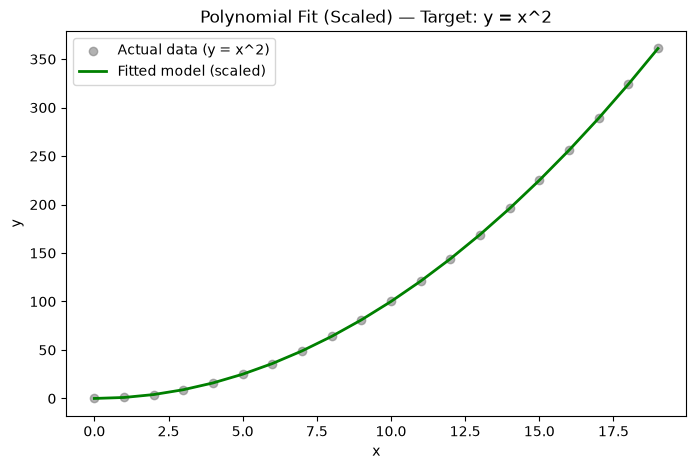

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='gray', label='Actual data (y = x^2)', alpha=0.6)
plt.plot(x, model_scaled.predict(X_norm), color='green', label='Fitted model (scaled)', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Fit (Scaled) — Target: y = x^2')
plt.legend()
plt.show()

**Why this example is different** — `y = np.cos(x/2)` is not a polynomial at all — it's periodic. Polynomial features can still *approximate* a curve like this reasonably well over a limited range of `x`, which is why 13 polynomial features (`x` through `x**13`) are engineered here — giving the model enough flexibility to bend and curve to match the wave shape, even though no single one of these features is the "true" underlying relationship.

**`np.cos(x/2)`** — NumPy's element-wise cosine function; applied to every value in `x` at once (vectorized, same pattern as earlier examples), producing one cosine value per `x`.

Scaling is essential here — with exponents up to `x**13`, the magnitude gap between columns is enormous (e.g. at `x=19`: `x=19` vs `x**13` ≈ 3×10¹⁶), so z-score normalization isn't optional at this degree; without it, both numerical stability and coefficient interpretability break down.

In [18]:
x = np.arange(0, 20, 1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X_norm, mu, sigma = zscore_normalize_features(X)

model_cos = LinearRegression()
model_cos.fit(X_norm, y)
y_pred_cos = model_cos.predict(X_norm)

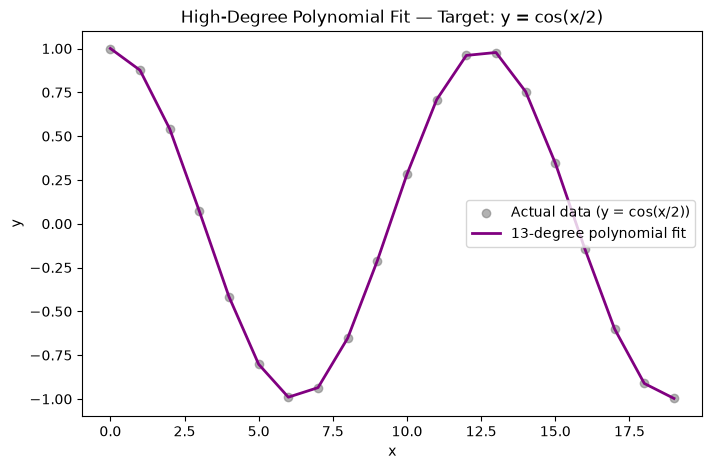

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='gray', label='Actual data (y = cos(x/2))', alpha=0.6)
plt.plot(x, y_pred_cos, color='purple', label='13-degree polynomial fit', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('High-Degree Polynomial Fit — Target: y = cos(x/2)')
plt.legend()
plt.show()